In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import os
import itertools
import numpy as np
import pandas as pd

In [3]:
def read_chibio(file_name, emissions=None, overlay=False):
    m = pd.read_csv(file_name)
    
    if emissions is None:
        emissions = [x for x in m.columns
                     if x.startswith('FP')
                     and not x.endswith('base')]

    # get time in hours
    m['time'] = m['exp_time'] / 60 / 60
    # get log of the OD
    m['ln(od)'] = np.log(m['od_measured'])

    # create a timedelta index
    m.index = pd.to_timedelta(m['time'], unit='h')
    # smooth OD readings taking the median over a sliding 10-minute window
    m['smooth_od'] = m.rolling('60min', min_periods=5)['od_measured'].median()
    # smooth emission readings taking the median over a sliding 10-minute window
    for em in emissions:
        m[f'smooth_{em}'] = m.rolling('60min', min_periods=5)[em].median()
        m[f'smooth_norm_{em}'] = m[f'smooth_{em}'] / m['smooth_od']
        m[f'norm_{em}'] = m[em] / (m['od_measured'] + 1)

    for em1, em2 in itertools.combinations(emissions, 2):
        m[f'{em1}_{em2}_ratio'] = m[em1] / m[em2]
        m[f'smooth_{em1}_{em2}_ratio'] = m[f'smooth_{em1}'] / m[f'smooth_{em2}']
        m[f'norm_{em1}_{em2}_ratio'] = m[f'norm_{em1}'] / m[f'norm_{em2}']
    
    return m

In [4]:
d = {(0, 0.1): ('M9', 'white'),
     (0.1, 0.21): ('PL', 'xkcd:teal'),
     (0.21, 0.32): ('PM', 'xkcd:pale red'),
     (0.32, 0.44): ('LM', 'grey'),
     (0.44, 0.55): ('PLPMLM', '#898d86'),
     (0.55, 0.66): ('plPMLM', '#c28a86'),
     (0.66, 0.77): ('PLpmLM', '#66a59e'),
     (0.77, 0.88): ('PLPMlm', '#71776e'),
     (0.88, 0.99): ('plpmLM', '#b1b2b1'),
     (0.99, 1.1): ('plPMlm', '#c5625b'),
     (1.1, 1.2): ('PLpmlm', '#249186')}

In [5]:
m = read_chibio('2024-06-19 18_42_54_M7_data.csv')

In [6]:
# remove last time point
m = m[m['time'] < 1.2]

In [7]:
cols = ['time',
        'od_measured', 'ln(od)',
        'FP1_emit1', 'FP2_emit1',
        'norm_FP1_emit1', 'norm_FP2_emit1',
        'FP1_emit1_FP2_emit1_ratio']

In [8]:
res = []
for (x, y), (label, color) in d.items():
    for idx, row in m[(m['time'] >= x) & (m['time'] <= y)].iterrows():
        values = [row[col] for col in cols]
        res.append([label, color] + values)
n = pd.DataFrame(res,
                 columns=['label', 'color'] + cols)
n.to_csv('calibration.tsv', sep='\t', index=False)

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

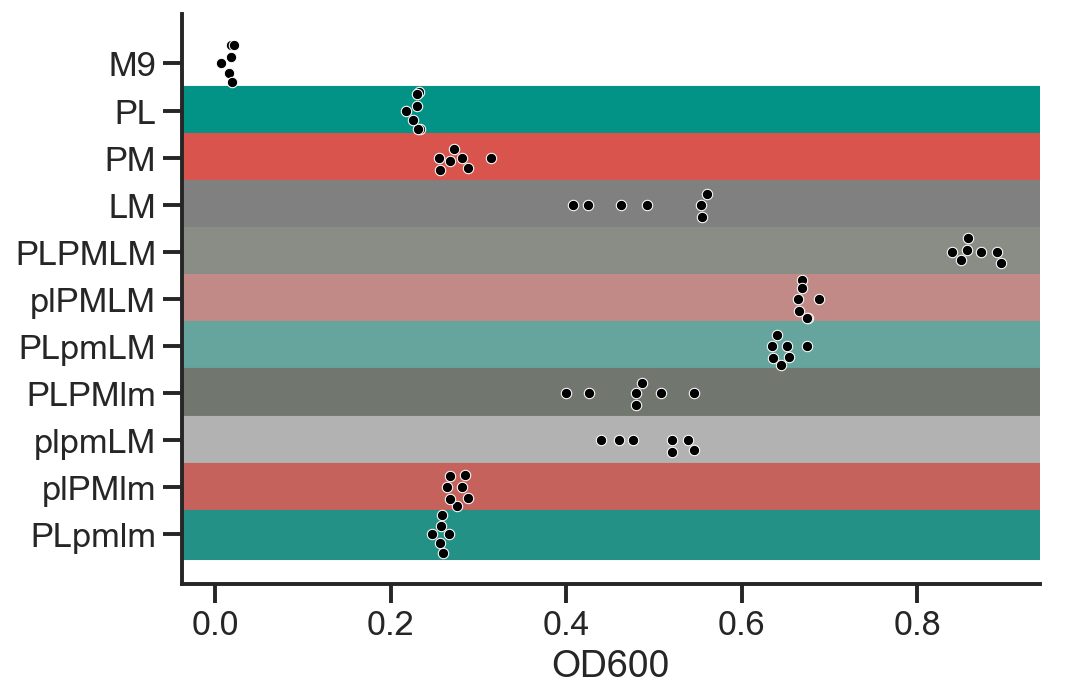

In [9]:
cp = sns.catplot(data=n,
                 y='label', x='od_measured',
                 height=5, aspect=1.5,
                 color='k',
                 linewidth=0.5,
                 edgecolor='w',
                 kind='swarm')
plt.ylabel('')
plt.xlabel('OD600')
for i, ((x, y), (label, color)) in enumerate(d.items()):
    plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
                 color=color,
                 zorder=-1)

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

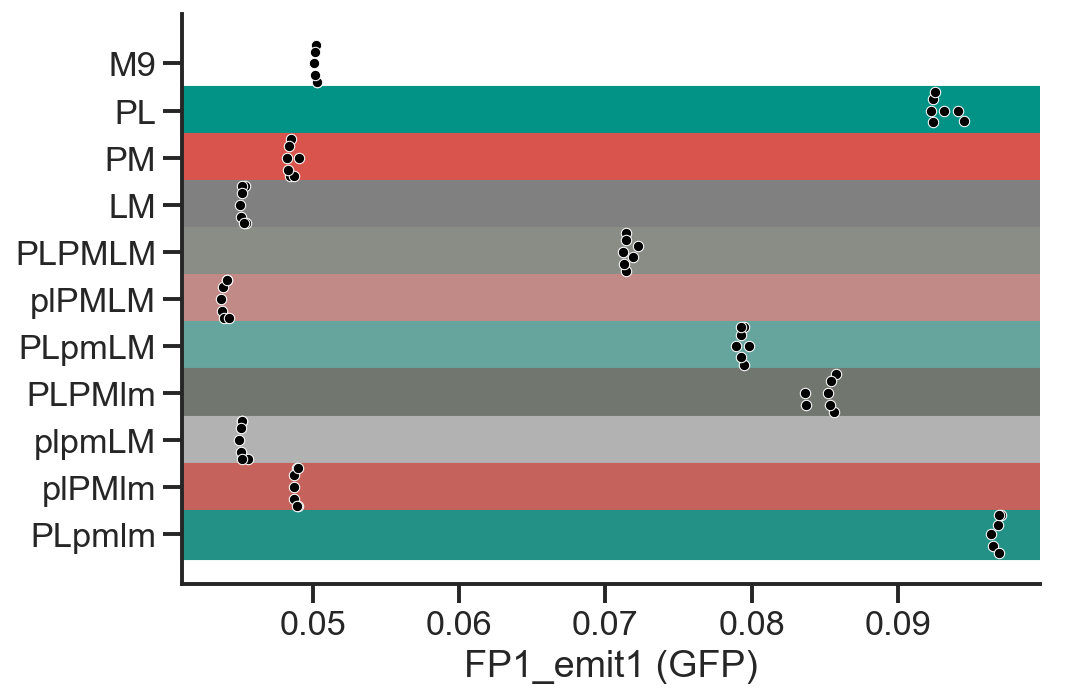

In [10]:
cp = sns.catplot(data=n,
                 y='label', x='FP1_emit1',
                 height=5, aspect=1.5,
                 color='k',
                 linewidth=0.5,
                 edgecolor='w',
                 kind='swarm')
plt.ylabel('')
plt.xlabel('FP1_emit1 (GFP)')
for i, ((x, y), (label, color)) in enumerate(d.items()):
    plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
                 color=color,
                 zorder=-1)

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

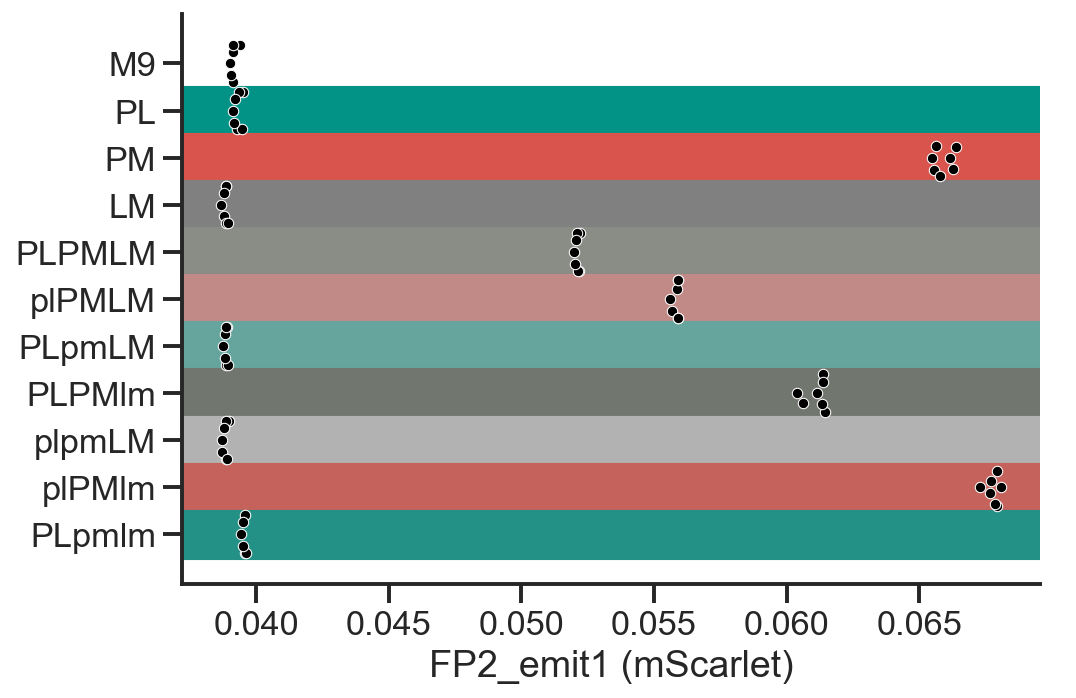

In [11]:
cp = sns.catplot(data=n,
                 y='label', x='FP2_emit1',
                 height=5, aspect=1.5,
                 color='k',
                 linewidth=0.5,
                 edgecolor='w',
                 kind='swarm')
plt.ylabel('')
plt.xlabel('FP2_emit1 (mScarlet)')
for i, ((x, y), (label, color)) in enumerate(d.items()):
    plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
                 color=color,
                 zorder=-1)

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

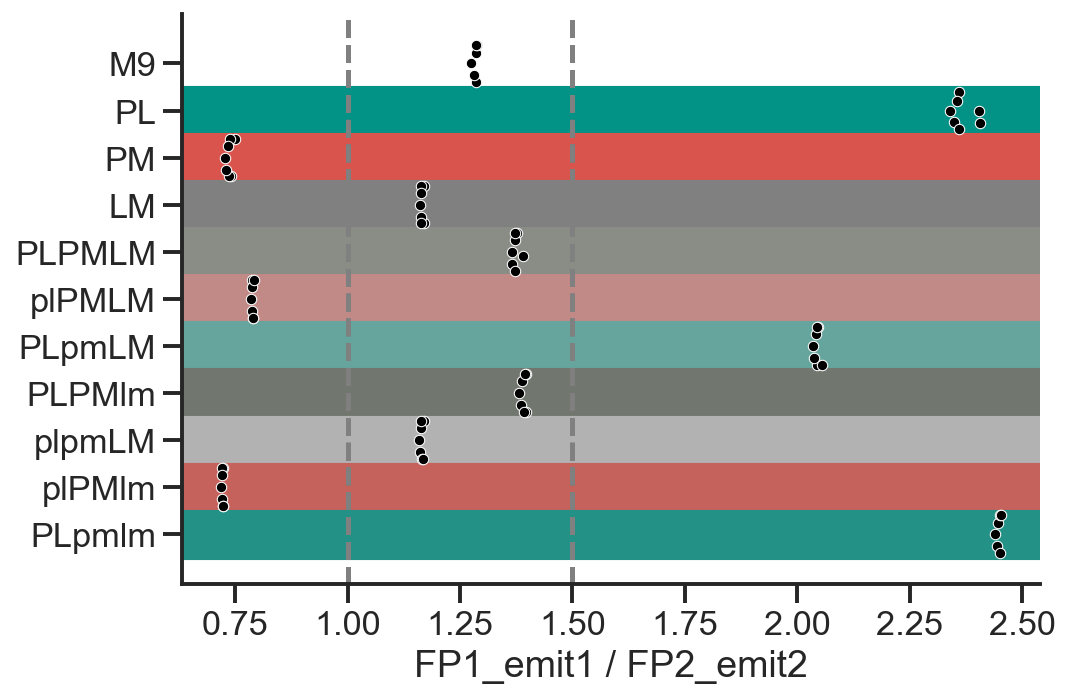

In [12]:
cp = sns.catplot(data=n,
                 y='label', x='FP1_emit1_FP2_emit1_ratio',
                 height=5, aspect=1.5,
                 color='k',
                 linewidth=0.5,
                 edgecolor='w',
                 kind='swarm')
plt.ylabel('')
plt.xlabel('FP1_emit1 / FP2_emit2')
for i, ((x, y), (label, color)) in enumerate(d.items()):
    plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
                 color=color,
                 zorder=-1)
    plt.axvline(1, color='grey', ls='dashed')
    plt.axvline(1.5, color='grey', ls='dashed')

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

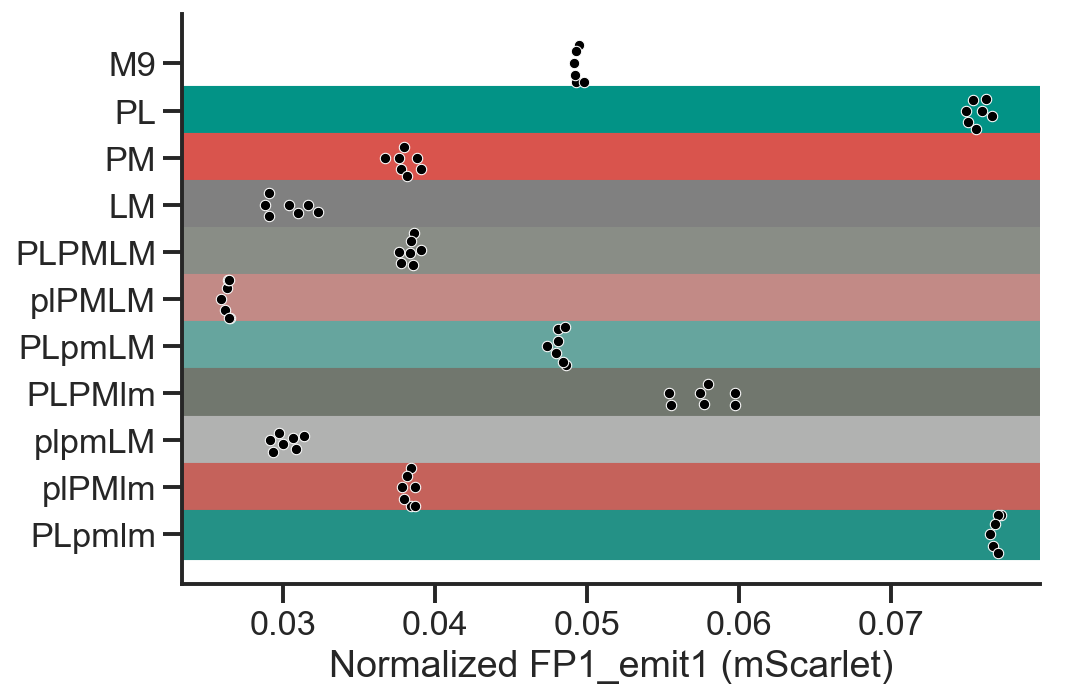

In [13]:
cp = sns.catplot(data=n,
                 y='label', x='norm_FP1_emit1',
                 height=5, aspect=1.5,
                 color='k',
                 linewidth=0.5,
                 edgecolor='w',
                 kind='swarm')
plt.ylabel('')
plt.xlabel('Normalized FP1_emit1 (mScarlet)')
for i, ((x, y), (label, color)) in enumerate(d.items()):
    plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
                 color=color,
                 zorder=-1)

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

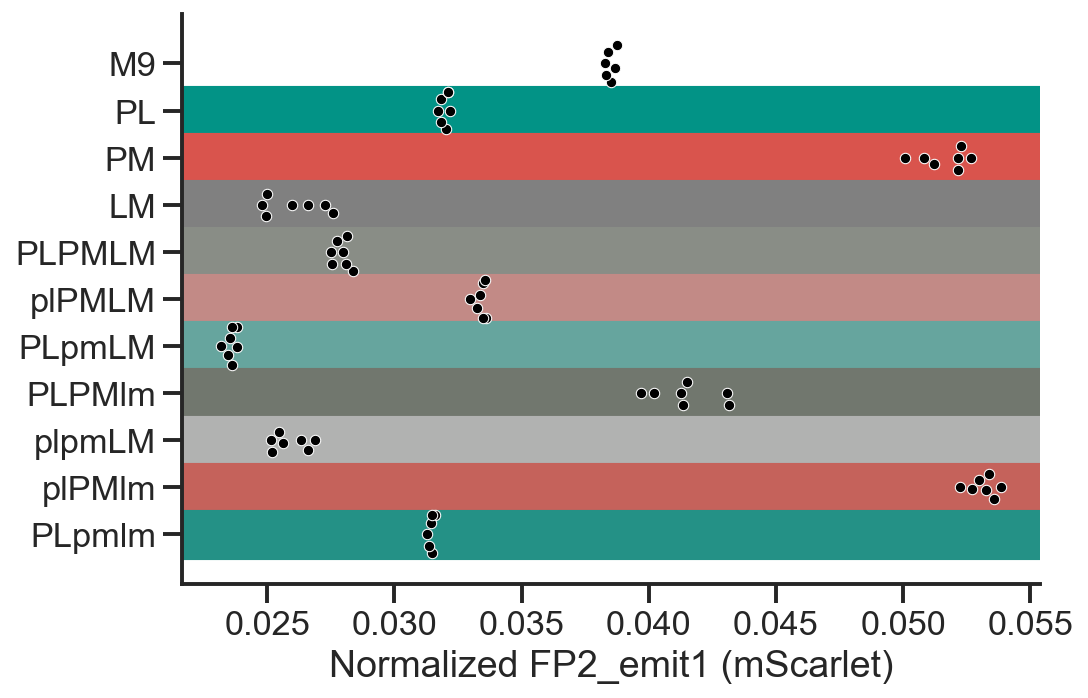

In [14]:
cp = sns.catplot(data=n,
                 y='label', x='norm_FP2_emit1',
                 height=5, aspect=1.5,
                 color='k',
                 linewidth=0.5,
                 edgecolor='w',
                 kind='swarm')
plt.ylabel('')
plt.xlabel('Normalized FP2_emit1 (mScarlet)')
for i, ((x, y), (label, color)) in enumerate(d.items()):
    plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
                 color=color,
                 zorder=-1)

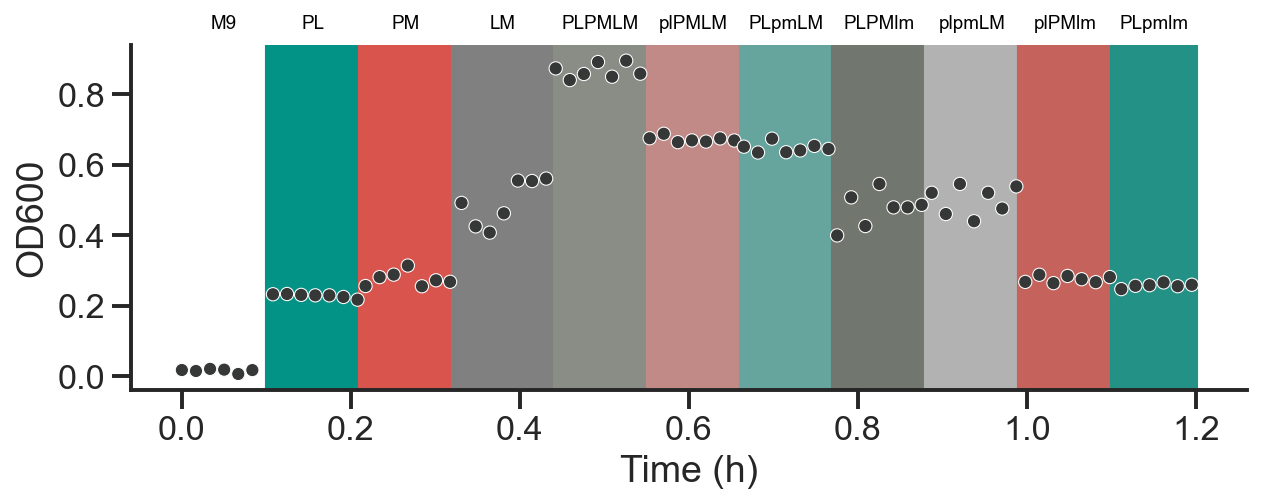

In [15]:
cp = sns.relplot(data=m,
                 x='time',
                 y='od_measured',
                 size=5,
                 height=3.5, aspect=2.5,
                 color='xkcd:dark grey',
                 legend=False,
                )

for (x, y), (label, color) in d.items():
    plt.axvspan(xmin=x, xmax=y,
                 color=color,
                 zorder=-1)
    plt.text((x + y) / 2, 1, label,
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=9,
             color='black')

plt.ylabel('OD600')
plt.xlabel('Time (h)');

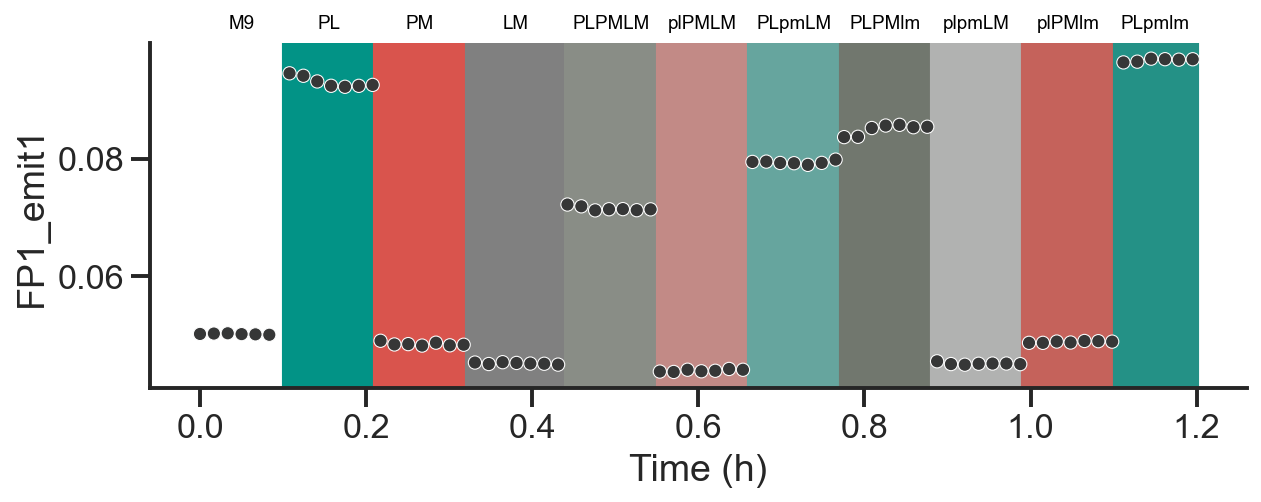

In [16]:
cp = sns.relplot(data=m,
                 x='time',
                 y='FP1_emit1',
                 size=5,
                 height=3.5, aspect=2.5,
                 color='xkcd:dark grey',
                 legend=False,
                )

for (x, y), (label, color) in d.items():
    plt.axvspan(xmin=x, xmax=y,
                 color=color,
                 zorder=-1)
    plt.text((x + y) / 2, 0.103, label,
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=9,
             color='black')

plt.ylabel('FP1_emit1')
plt.xlabel('Time (h)');

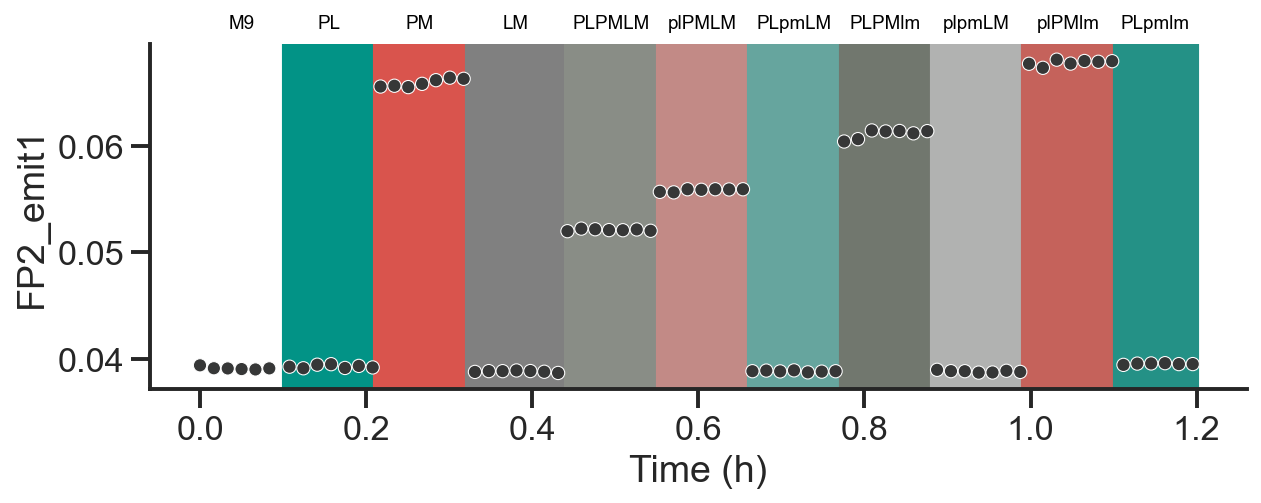

In [17]:
cp = sns.relplot(data=m,
                 x='time',
                 y='FP2_emit1',
                 size=5,
                 height=3.5, aspect=2.5,
                 color='xkcd:dark grey',
                 legend=False,
                )

for (x, y), (label, color) in d.items():
    plt.axvspan(xmin=x, xmax=y,
                 color=color,
                 zorder=-1)
    plt.text((x + y) / 2, 0.0715, label,
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=9,
             color='black')

plt.ylabel('FP2_emit1')
plt.xlabel('Time (h)');

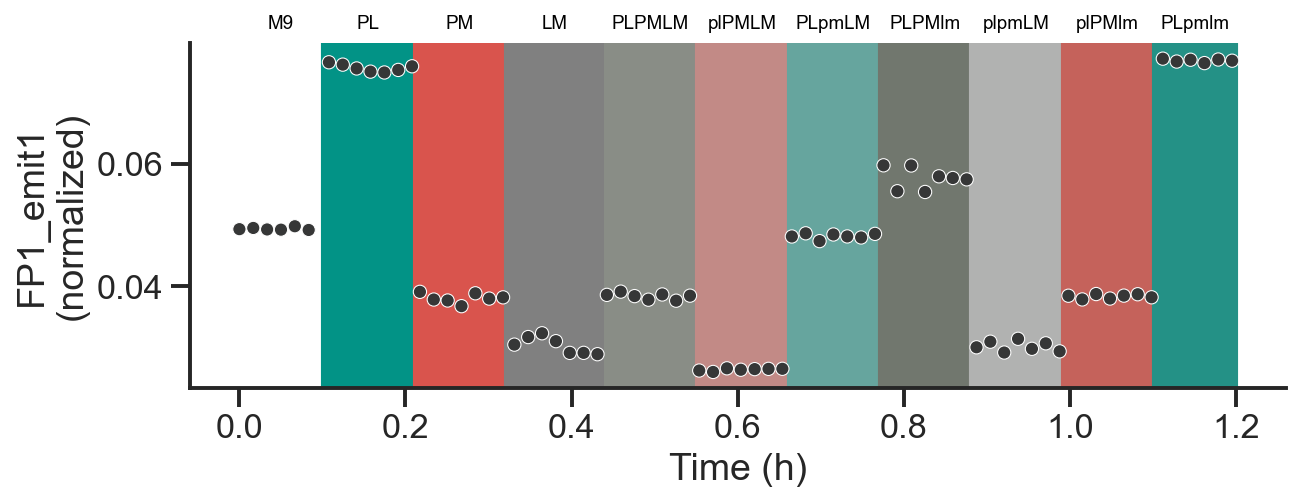

In [18]:
cp = sns.relplot(data=m,
                 x='time',
                 y='norm_FP1_emit1',
                 size=5,
                 height=3.5, aspect=2.5,
                 color='xkcd:dark grey',
                 legend=False,
                )

for (x, y), (label, color) in d.items():
    plt.axvspan(xmin=x, xmax=y,
                 color=color,
                 zorder=-1)
    plt.text((x + y) / 2, 0.083, label,
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=9,
             color='black')

plt.ylabel('FP1_emit1\n(normalized)')
plt.xlabel('Time (h)');

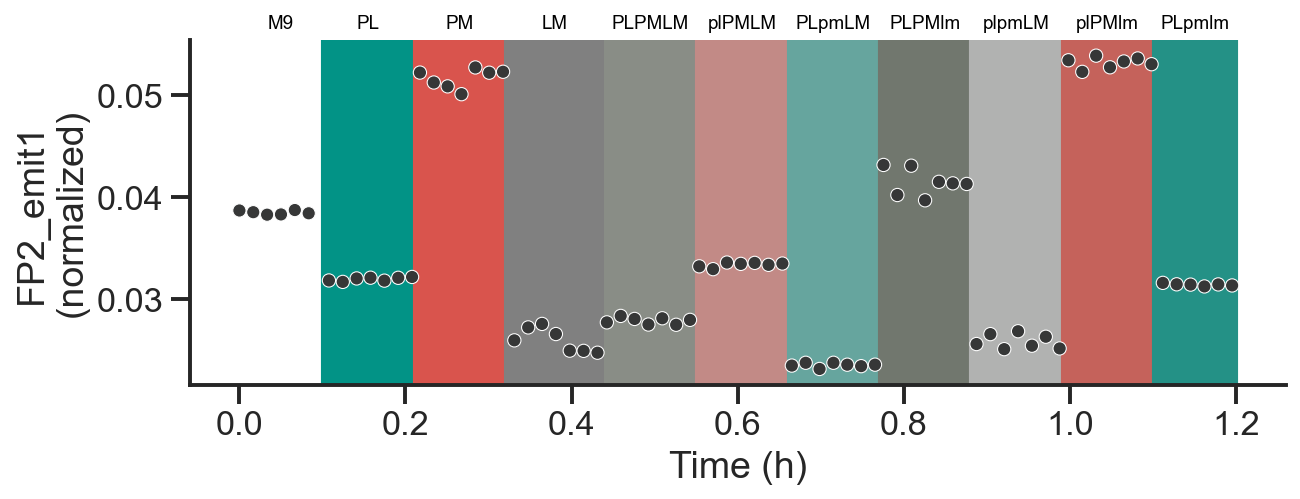

In [19]:
cp = sns.relplot(data=m,
                 x='time',
                 y='norm_FP2_emit1',
                 size=5,
                 height=3.5, aspect=2.5,
                 color='xkcd:dark grey',
                 legend=False,
                )

for (x, y), (label, color) in d.items():
    plt.axvspan(xmin=x, xmax=y,
                 color=color,
                 zorder=-1)
    plt.text((x + y) / 2, 0.057, label,
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=9,
             color='black')

plt.ylabel('FP2_emit1\n(normalized)')
plt.xlabel('Time (h)');